In [ ]:
"""
generate embeddings using different approaches.
use the arXiv API to gather 500 research papers,
then generate embeddings using both local models and cloud services.

so as to understand the tradeoffs and be able to make informed decisions 
for other projects
"""

import os
import time

import arxiv
import pandas as pd
from cohere import ClientV2
# from dotenv import load_dotenv
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer


ModuleNotFoundError: No module named 'dotenv'

In [2]:
### Create the arXiv client once and reuse it
### This is recommended by the arxiv package to respect rate limits
client = arxiv.Client()

In [3]:

def collect_arxiv_papers(category, max_results=100):
    """
    Collect papers from arXiv by category.

    Parameters:'[]
    -----------
    category : str
        arXiv category code (e.g., 'cs.LG', 'cs.CV')
    max_results : int
        Maximum number of papers to retrieve

    Returns:
    --------
    list of dict
        List of paper dictionaries containing title, abstract, authors, etc.
    """
    # Construct search query for the category
    search = arxiv.Search(
        query=f"cat:{category}",
        max_results=max_results,
        sort_by=arxiv.SortCriterion.SubmittedDate
    )

    papers = []
    for result in client.results(search):
        paper = {
            'title': result.title,
            'abstract': result.summary,
            'authors': [author.name for author in result.authors],
            'published': result.published,
            'category': category,
            'arxiv_id': result.entry_id.split('/')[-1]
        }
        papers.append(paper)

    return papers

### Define the categories we want to collect from
categories = [
    ('cs.LG', 'Machine Learning'),
    ('cs.CV', 'Computer Vision'),
    ('cs.CL', 'Computational Linguistics'),
    ('cs.DB', 'Databases'),
    ('cs.SE', 'Software Engineering')
]

### Collect 100 papers from each category
all_papers = []
for category_code, category_name in categories:
    print(f"Collecting papers from {category_name} ({category_code})...")
    papers = collect_arxiv_papers(category_code, max_results=100)
    all_papers.extend(papers)
    print(f"  Collected {len(papers)} papers")

print(f"\nTotal papers collected: {len(all_papers)}")

### Let's examine the first paper from each category
separator = "=" * 80
print(f"\n{separator}", "SAMPLE PAPERS (one from each category)", f"{separator}", sep="\n")
for i, (_, category_name) in enumerate(categories):
    paper = all_papers[i * 100]
    print(f"\n{category_name}:")
    print(f"  Title: {paper['title']}")
    print(f"  Abstract (first 150 chars): {paper['abstract'][:150]}...")

  Collected 100 papers
  Collected 100 papers
  Collected 100 papers
  Collected 100 papers
  Collected 100 papers

Total papers collected: 500

SAMPLE PAPERS (one from each category)

Machine Learning:
  Title: Drive My Way: Preference Alignment of Vision-Language-Action Model for Personalized Driving
  Abstract (first 150 chars): Human driving behavior is inherently personal, which is shaped by long-term habits and influenced by short-term intentions. Individuals differ in how ...

Computer Vision:
  Title: ShotStream: Streaming Multi-Shot Video Generation for Interactive Storytelling
  Abstract (first 150 chars): Multi-shot video generation is crucial for long narrative storytelling, yet current bidirectional architectures suffer from limited interactivity and ...

Computational Linguistics:
  Title: Training the Knowledge Base through Evidence Distillation and Write-Back Enrichment
  Abstract (first 150 chars): The knowledge base in a retrieval-augmented generation (RAG) system is 

In [6]:
df = pd.DataFrame(all_papers)

In [7]:
df.to_csv("arxiv_papers_20260328.csv", index=False)

In [8]:
df.to_json("arxiv_papers_20260328.json", orient="records")

In [ ]:


print("Dataset before cleaning:")
print(f"Total papers: {len(df)}")
print(f"Papers with abstracts: {df['abstract'].notna().sum()}")

"""
you can leave this section out as pandas 2.3.3 will automatically remove na in >= 100 comparison.
df['abstract'].str.len() assigns NaN to abstract_lengh, for the value with None
"""
#
### Check for missing abstracts
missing_abstracts = df['abstract'].isna().sum()
if missing_abstracts > 0:
    print(f"\nWarning: {missing_abstracts} papers have missing abstracts")
    df = df.dropna(subset=['abstract'])

### Filter out papers with very short abstracts (less than 100 characters)
### These are often just placeholders or incomplete entries
df['abstract_length'] = df['abstract'].str.len()
df = df[df['abstract_length'] >= 100].copy()

print(f"\nDataset after cleaning:")
print(f"Total papers: {len(df)}")
print(f"Average abstract length: {df['abstract_length'].mean():.0f} characters")

### Show the distribution across categories
print("\nPapers per category:")
print(df['category'].value_counts().sort_index())

### Display the first few entries
separator = "=" * 80
print(f"\n{separator}", "FIRST 3 PAPERS IN CLEANED DATASET", f"{separator}", sep="\n")
for idx, row in df.head(3).iterrows():
    print(f"\n{idx+1}. {row['title']}")
    print(f"   Category: {row['category']}")
    print(f"   Abstract length: {row['abstract_length']} characters")

Dataset before cleaning:
Total papers: 499
Papers with abstracts: 499

Dataset after cleaning:
Total papers: 499
Average abstract length: 1370 characters

Papers per category:
category
cs.CL    100
cs.CV    100
cs.DB    100
cs.LG     99
cs.SE    100
Name: count, dtype: int64

FIRST 3 PAPERS IN CLEANED DATASET

2. No Hard Negatives Required: Concept Centric Learning Leads to Compositionality without Degrading Zero-shot Capabilities of Contrastive Models
   Category: cs.LG
   Abstract length: 1604 characters

3. Agent Factories for High Level Synthesis: How Far Can General-Purpose Coding Agents Go in Hardware Optimization?
   Category: cs.LG
   Abstract length: 1498 characters

4. Neural Network Conversion of Machine Learning Pipelines
   Category: cs.LG
   Abstract length: 1090 characters


In [54]:
print("Loading all-MiniLM-L6-v2 model...")
model_small = SentenceTransformer('all-MiniLM-L6-v2')

### Generate embeddings for all abstracts
abstracts = df['abstract'].tolist()

Loading all-MiniLM-L6-v2 model...


In [55]:
print(f"Generating embeddings for {len(abstracts)} papers...")
start_time = time.time()

### The encode() method handles batching automatically
embeddings_small = model_small.encode(
    abstracts,
    show_progress_bar=True,
    batch_size=32  # Process 32 abstracts at a time
)

elapsed_time = time.time() - start_time

print(f"\nCompleted in {elapsed_time:.2f} seconds")
print(f"Embedding shape: {embeddings_small.shape}")
print(f"Each abstract is now a {embeddings_small.shape[1]}-dimensional vector")
print(f"Average time per abstract: {elapsed_time/len(abstracts):.3f} seconds")

### Add embeddings to our DataFrame
df['embedding_minilm'] = list(embeddings_small)

Generating embeddings for 500 papers...


Batches: 100%|██████████| 16/16 [00:03<00:00,  5.18it/s]


Completed in 3.15 seconds
Embedding shape: (500, 384)
Each abstract is now a 384-dimensional vector
Average time per abstract: 0.006 seconds


In [56]:
### Load a larger (more dimensions) model
print("\nLoading all-mpnet-base-v2 model...")
model_large = SentenceTransformer('all-mpnet-base-v2')


Loading all-mpnet-base-v2 model...


In [57]:
print("Generating embeddings with larger model...")
start_time = time.time()

embeddings_large = model_large.encode(
    abstracts,
    show_progress_bar=True,
    batch_size=32
)

elapsed_time = time.time() - start_time

print(f"\nCompleted in {elapsed_time:.2f} seconds")
print(f"Embedding shape: {embeddings_large.shape}")
print(f"Each abstract is now a {embeddings_large.shape[1]}-dimensional vector")
print(f"Average time per abstract: {elapsed_time/len(abstracts):.3f} seconds")

### Add these embeddings to our DataFrame too
df['embedding_mpnet'] = list(embeddings_large)

Generating embeddings with larger model...


Batches: 100%|██████████| 16/16 [00:17<00:00,  1.12s/it]


Completed in 17.91 seconds
Embedding shape: (500, 768)
Each abstract is now a 768-dimensional vector
Average time per abstract: 0.036 seconds


In [59]:
### Reduce embeddings from 384 dimensions to 2 dimensions
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_small)

print(f"Original embedding dimensions: {embeddings_small.shape[1]}")
print(f"Reduced embedding dimensions: {embeddings_2d.shape[1]}")

Original embedding dimensions: 384
Reduced embedding dimensions: 2


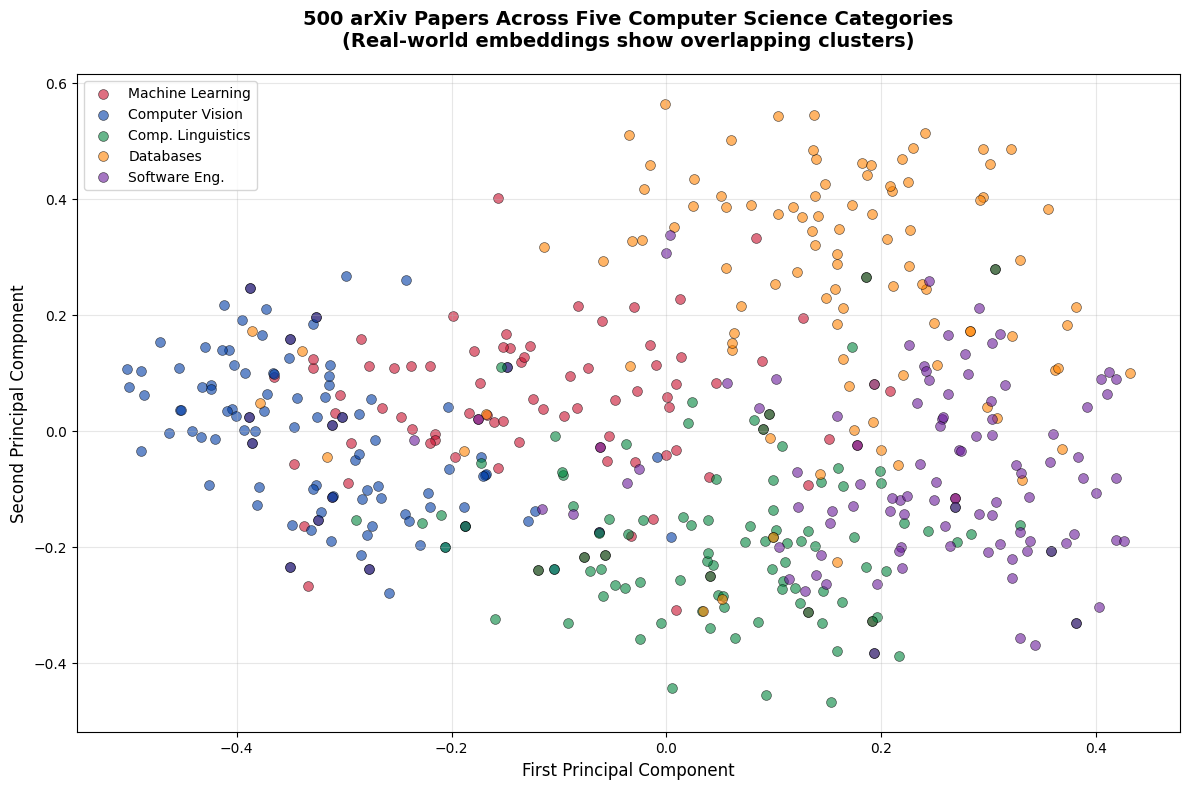

In [60]:
### Create the visualization
plt.figure(figsize=(12, 8))

### Define colors for different categories
colors = ['#C8102E', '#003DA5', '#00843D', '#FF8200', '#6A1B9A']
category_names = ['Machine Learning', 'Computer Vision', 'Comp. Linguistics', 'Databases', 'Software Eng.']
category_codes = ['cs.LG', 'cs.CV', 'cs.CL', 'cs.DB', 'cs.SE']

### Plot each category
for i, (cat_code, cat_name, color) in enumerate(zip(category_codes, category_names, colors)):
    # Get papers from this category
    mask = df['category'] == cat_code
    cat_embeddings = embeddings_2d[mask]

    plt.scatter(cat_embeddings[:, 0], cat_embeddings[:, 1],
                c=color, label=cat_name, s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('500 arXiv Papers Across Five Computer Science Categories\n(Real-world embeddings show overlapping clusters)',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# using Cohere hosted model

!COHERE_API_KEY=your_key_here

# ### Load environment variables from .env file
# load_dotenv()

### Access your API key
cohere_api_key = os.getenv('COHERE_API_KEY')

if not cohere_api_key:
    raise ValueError(
        "COHERE_API_KEY not found. Please create a .env file with your API key.\n"
        "See https://dashboard.cohere.com for instructions on getting your key."
    )

### Initialize the Cohere client using the V2 API
co = ClientV2(api_key=cohere_api_key)
print("API key loaded successfully from environment")

In [ ]:
print("Generating embeddings using Cohere API...")
print(f"Processing {len(abstracts)} abstracts...")

start_time = time.time()
actual_api_time = 0  # Track time spent on actual API calls

### Cohere recommends processing in batches for efficiency
### Their API accepts up to 96 texts per request
batch_size = 90
all_embeddings = []

for i in range(0, len(abstracts), batch_size):
    batch = abstracts[i:i+batch_size]
    batch_num = i//batch_size + 1
    total_batches = (len(abstracts) + batch_size - 1) // batch_size
    print(f"Processing batch {batch_num}/{total_batches} ({len(batch)} abstracts)...")

    # Add retry logic for rate limits
    max_retries = 3
    retry_delay = 60  # Wait 60 seconds if we hit rate limit

    for attempt in range(max_retries):
        try:
            # Track actual API call time
            api_start = time.time()

            # Generate embeddings for this batch using V2 API
            response = co.embed(
                texts=batch,
                model='embed-v4.0',
                input_type='search_document',
                embedding_types=['float']
            )

            actual_api_time += time.time() - api_start
            # V2 API returns embeddings in a different structure
            all_embeddings.extend(response.embeddings.float_)
            break  # Success, move to next batch

        except Exception as e:
            if "rate limit" in str(e).lower() and attempt < max_retries - 1:
                print(f"  Rate limit hit. Waiting {retry_delay} seconds before retry...")
                time.sleep(retry_delay)
            else:
                raise  # Re-raise if it's not a rate limit error or we're out of retries

    # Add a delay between batches to avoid hitting rate limits
    # Wait 12 seconds between batches (spreads 500 papers over ~1 minute)
    if i + batch_size < len(abstracts):  # Don't wait after the last batch
        time.sleep(12)

### Convert to numpy array for consistency with local models
embeddings_cohere = np.array(all_embeddings)
elapsed_time = time.time() - start_time

print(f"\nCompleted in {elapsed_time:.2f} seconds (includes rate limit delays)")
print(f"Actual API processing time: {actual_api_time:.2f} seconds")
print(f"Time spent waiting for rate limits: {elapsed_time - actual_api_time:.2f} seconds")
print(f"Embedding shape: {embeddings_cohere.shape}")
print(f"Each abstract is now a {embeddings_cohere.shape[1]}-dimensional vector")
print(f"Average time per abstract (API only): {actual_api_time/len(abstracts):.3f} seconds")

### Add to DataFrame
df['embedding_cohere'] = list(embeddings_cohere)

In [ ]:
"""
Key Takeaways:

- Programmatic data collection through APIs like arXiv enables working with real-world datasets

- Collecting papers from diverse categories (cs.LG, cs.CV, cs.CL, cs.DB, cs.SE) creates
semantic clusters for effective search

- Papers can be cross-listed in multiple arXiv categories, creating natural overlap between related fields

- Self-hosted embedding models provide zero-cost, private embedding generation with
full control over the process

- API-based embedding services offer high-quality embeddings without infrastructure management

- Secure credential handling using .env files protects sensitive API keys and tokens

- Rate limits aren't always clearly documented and are sometimes discovered through trial and error

- The choice between self-hosted and API approaches depends on cost, privacy, scale, and
infrastructure considerations

- Free tier APIs provide powerful embedding generation for learning, but require handling rate
limits and delays that paid tiers avoid

- Real-world embeddings show more overlap than handcrafted examples, reflecting the complexity
of actual data

- Proper storage of embeddings prevents costly regeneration and enables efficient reuse across projects
"""

"\nKey Takeaways:\n\n- Programmatic data collection through APIs like arXiv enables working with real-world datasets\n\n- Collecting papers from diverse categories (cs.LG, cs.CV, cs.CL, cs.DB, cs.SE) creates\nsemantic clusters for effective search\n\n- Papers can be cross-listed in multiple arXiv categories, creating natural overlap between related fields\n\n- Self-hosted embedding models provide zero-cost, private embedding generation with\nfull control over the process\n\n- API-based embedding services offer high-quality embeddings without infrastructure management\n\n- Secure credential handling using .env files protects sensitive API keys and tokens\n\n- Rate limits aren't always clearly documented and are sometimes discovered through trial and error\n\n- The choice between self-hosted and API approaches depends on cost, privacy, scale, and\ninfrastructure considerations\n\n- Free tier APIs provide powerful embedding generation for learning, but require handling rate\nlimits and de

In [ ]:
"""
Experiment with different arXiv categories:

Try collecting papers from categories like stat.ML (Statistics Machine Learning) or math.OC (Optimization and Control)
Use the PCA visualization code to see how these new categories cluster with your existing five
Do some categories overlap more than others?
Compare embedding models visually:

Generate embeddings for your dataset using all-mpnet-base-v2
Create side-by-side PCA visualizations comparing the small model and large model
Do the clusters look tighter or more separated with the larger model?
Test different dataset sizes:

Collect just 50 papers per category (250 total) and visualize the results
Then try 200 papers per category (1000 total)
How does dataset size affect the clarity of the clusters?
At what point does collection or processing time become noticeable?
Explore model differences:

Visit Hugging Face's sentence similarity models (https://huggingface.co/models?pipeline_tag=sentence-similarity)
Try a domain-specific model optimized for scientific text
Compare the embeddings qualitatively by looking at which papers cluster together
Ready to implement similarity search and build a working semantic search engine? The next lesson will show you how to turn these embeddings into a powerful research discovery tool.
"""